In [4]:
%matplotlib inline
import sys
sys.path.append('../functions')
import numpy as np
#import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
#import torch
import pandas as pd
import multiprocessing
import time
from sklearn.model_selection import ParameterGrid
import linear_sim_func  

# One simulation 

In [2]:
N_v = [60]
N_test_v = [500]
p_v = [40]
error_sd_v = [1]
L_v = [0.9]
level_v = [0.2]
use_true_contour_v = [True]
n_boot_v = [2000]
ridge_penal_v = [[1,0.5,1e-1, 1e-2, 1e-3, 1e-4]]
#ridge_penal_v = [None]
MC_v = [False]
second_stage_v = [False]
center_G_v = [True]
center_pred_v = [True]
residual_boot_v = [False]
CV_boot_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,
              'ridge_penal':ridge_penal_v, 'MC':MC_v, 'second_stage':second_stage_v,
              'center_G':center_G_v, 'center_pred':center_G_v,
              'residual_boot':residual_boot_v, 'CV_boot':CV_boot_v}
param_grid = ParameterGrid(param_grid)
for param in param_grid:
    l = linear_sim_func.sim_linear(param['N'], param['N_test'], param['p'], param['error_sd'], 
                          param['L'],param['level'],param['use_true_contour'], param['n_boot'], 
                            param['ridge_penal'], param['MC'], param['second_stage'], 
                            param['center_G'], param['center_pred'], 
                            param['residual_boot'], param['CV_boot'])

> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(48)process_boot_samples()
     46     '''
     47     import pdb; pdb.set_trace()
---> 48     if MC:
     49         G = (mean_boot_l-mean_test_true)/se
     50     elif second_stage:



ipdb>  mean_boot_l.shape


(2000, 500)


ipdb>  n


> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(50)process_boot_samples()
     48     if MC:
     49         G = (mean_boot_l-mean_test_true)/se
---> 50     elif second_stage:
     51         mean_matrix, se = second_stage_boot(mean_boot_l)
     52         mean = np.mean(mean_boot_l, axis = 0)



...

> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(61)process_boot_samples()
     59             G = (mean_boot_l-mean)/se
     60         if center_pred:
---> 61             mean = np.mean(mean_boot_l, axis = 0)
     62     return G, mean, se
     63 



ipdb>  n


> /Users/juntingren/Desktop/prediction_uncertainty/functions/confidence_set_func.py(62)process_boot_samples()
     60         if center_pred:
     61             mean = np.mean(mean_boot_l, axis = 0)
---> 62     return G, mean, se
     63 
     64 class cal_thres_at_q(object):



ipdb>  q


BdbQuit: 

In [ ]:
l

In [26]:
mae

0.610364083223544

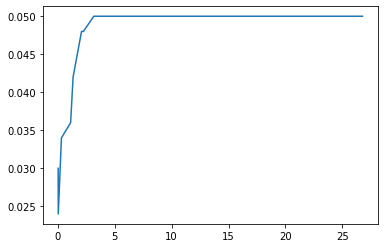

0.9500000000000028
0.974
True
0.752
0.9500000000000028
0.974
0.982
2


In [10]:
from matplotlib import pyplot as plt
x = [z[0] for z in range_v]
y = [z[1] for z in range_v]
plt.plot(x,y)
plt.show()
print(L)
print(U)
print(contain)
print(L1)
print(L2)
print(U1)
print(U2)
print(n_points)

# Bootstrap quantile vs True quantile

In [91]:
import bootstrap_func
from linear_sim_func import *
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
import confidence_set_func
# bootstrap
N_test = 500
p = 9
beta =None
error_sd = 1
X_test = None
n_boot = 500
smoothed = False
residual_boot = False
sparsity = 0
#bias_correction = True
if beta is None:
    rng = np.random.default_rng(None)
    beta = rng.standard_normal(size = p)
    if sparsity > 0:
        index_zero = rng.choice(range(p), size= int(p*sparsity))
        beta[index_zero] = 0
y,X, X_test, y_test,mean_test_true = generate_linear_data(N = 100, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
penal_sizes = [1,0.5,1e-1, 1e-2, 1e-3, 1e-4]

In [99]:
N = 400
ridge_penal = None
CV_boot = False
second_stage = False
n_sample_mean = 100
boot_sample_ratio = 1
second_stage = False
center_G = True
center_pred = False
pred_on_y = False

In [100]:
y,X, _,_, _ = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
if ridge_penal is not None:
    mean, se, mean_boot_l, mean_train = bootstrap_func.fit_bootstrap_ridge(y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot,  penal_sizes = penal_sizes, 
                                                               residual_boot = residual_boot, CV_boot = CV_boot, boot_sample_ratio = boot_sample_ratio)
else:# linear model without penality
    mean, se, mean_boot_l,mean_train = bootstrap_func.fit_bootstrap( y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot,residual_boot =  residual_boot, 
                                                                    boot_sample_ratio = boot_sample_ratio, pred_on_y = pred_on_y)
if second_stage:
    #mean = np.mean(mean_boot_l, axis = 0)
    mean_boot_l, se = confidence_set_func.second_stage_boot(mean_boot_l, n_sample = n_sample_mean)
mean_bias_cor1 = 2*mean - np.mean(mean_boot_l, axis = 0)
mean_bias_cor2 = mean - np.mean(mean_train - y)
if pred_on_y:
    mean_test_in = y_test
else:
    mean_test_in = mean_test_true
G, mean, se, mean_boot_l =confidence_set_func.process_boot_samples(mean_boot_l, mean, se, mean_test_in, 
                                      False, second_stage, center_G, center_pred, return_mean_boot_l = True)
# MCMC    
mean_MC_l = []
if second_stage:
    for i in range(n_boot):
        mean_MC_l_2 = []
        for j in range(n_sample_mean):
            y_new,X_new, X_test_trash,_, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
            if ridge_penal is not None:
                if CV_boot:
                    clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
                    mean_MC_l_2.append(clf.predict(X_test))
                else:
                    mean_MC_l_2.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
            else:# linear model without penality
                mean_MC_l_2.append(linear_fit_predict(y_new, X_new, X_test) )
        mean_MC_l.append(np.mean(mean_MC_l_2, axis = 0))
else:
    for i in range(n_boot):
        y_new,X_new, X_test_trash,_, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
        if ridge_penal is not None:
            if CV_boot:
                clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
                mean_MC_l.append(clf.predict(X_test))
            else:
                mean_MC_l.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
        else:# linear model without penality
            mean_MC_l.append(linear_fit_predict(y_new, X_new, X_test) )
mean_MC_l = np.array(mean_MC_l)
se_MC = np.std(mean_MC_l, axis = 0)
G, mean_MC, se_MC,mean_MC_l =confidence_set_func.process_boot_samples(mean_MC_l, mean, se_MC, mean_test_true, 
                                      True, second_stage, center_G, center_pred, return_mean_boot_l = True)
if smoothed:
    mean_MC = np.mean(mean_MC_l, axis = 0)
else:
    mean_MC = ridge_linear_fit_predict(y, X, X_test, ridge_penal) if ridge_penal is not None else linear_fit_predict(y, X, X_test) 

In [101]:
np.mean(se)

0.1475546781393919

In [29]:
np.mean(np.abs(mean_train - y))

0.7767831248125995

In [30]:
use_a_true = False
a_true = np.quantile(np.max(np.abs((mean_MC_l - mean_test_true)/se_MC),axis = 1), q = 0.975)
print(a_true)
minus_mean = np.mean(mean_boot_l, axis = 0)
#minus_mean = mean
a = np.quantile(np.max(np.abs((mean_boot_l - minus_mean)/se),axis = 1), q = 0.975)
print(a)
est = mean
#est = mean_bias_cor1
if use_a_true:
    print(np.all(np.logical_and(est+a_true*se>mean_test_in, est - a_true*se < mean_test_in)))
else:
    print(np.all(np.logical_and(est+a*se>mean_test_in, est - a*se < mean_test_in)))

3.8046856661569386
3.4447700855901386
True


In [31]:
#np.logical_and(est+a*se>mean_test_in, est - a*se < mean_test_in)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [32]:
print(np.mean(se_MC-se))
print(np.mean(a_true*se_MC-a*se))

-0.8943548326045222
-2.9704934262155764


1.1453866999524656
0.3050145184295502
1.3548610673944965
0.3894248724814802
1.1747431157256685
0.3007900025036368
0.38895499952006846
-0.7311149225262275
1.1580927122781266
0.30891229101059076
-1.2504738863390694
-2.3788864432166497
1.1359691462262584
0.2565178595949687
4.878516466050162
3.311225949738239
1.1453866999524656
0.3050145184295502
1.3548610673944965
0.3894248724814802
1.093220480701743
0.15469793994285616
2.752980339246694
1.1850350850531075
1.1877251281169228
0.38176157244451664
1.0834342143450593
0.38650002279045864
1.1728525184058245
0.3716806563898904
1.320945100356981
0.022346586312499847


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:33: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.


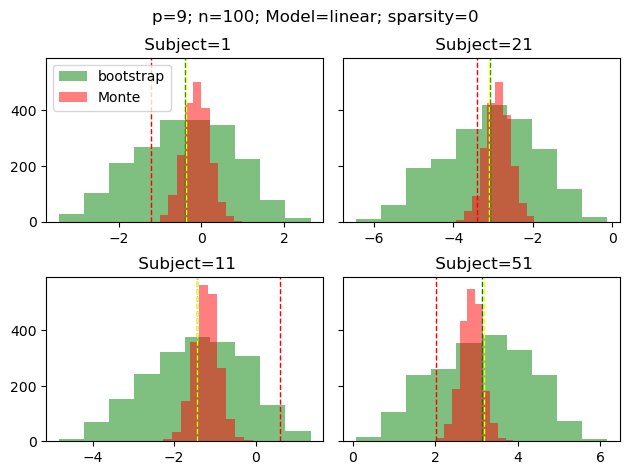

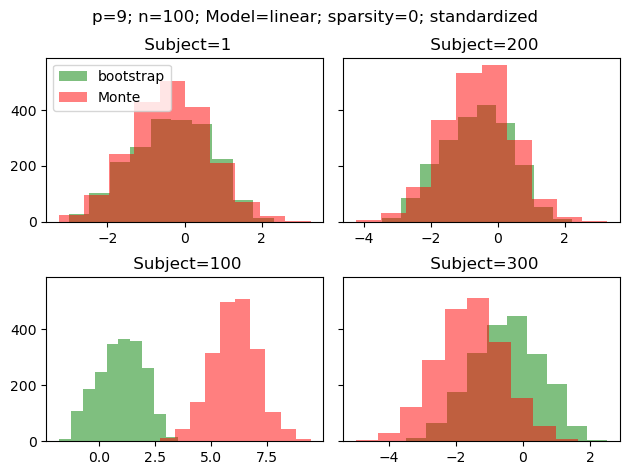

In [18]:
fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,11,21,51):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i], color = 'red', alpha=0.5, label = 'Monte')
    axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_test_in[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)
if second_stage:
    title = 'Second stage boot; '+ title
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')


fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,100,200,300):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i]/se[i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i]/se_MC[i], color = 'red', alpha=0.5, label = 'Monte')
    # axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    # #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
    # axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)+'; standardized'
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')

# G = (mean_boot_l-np.mean(mean_boot_l,axis = 0))/se
# #np.mean(mean_boot_l,axis = 0)
# G_MC = (mean_MC_l-mean_test_true)/se_MC
# plt.hist(G[:,i], color = 'yellow', alpha=0.5)
# plt.hist(G_MC[:,i], color = 'red', alpha=0.5)
# plt.show()
# print(np.std(G[:,i]))
# print(np.std(G_MC[:,i]))
# print(np.quantile(G[:,i], q = 0.95))
# print(np.quantile(G_MC[:,i], q = 0.95))
# print(np.quantile(G[:,i], q = 0.1))
# print(np.quantile(G_MC[:,i], q = 0.1))
# print(np.quantile(np.abs(G[:,i]), q = 0.95))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.95))
# print(np.quantile(np.abs(G[:,i]), q = 0.1))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.1))

# Neural nets

In [33]:
%matplotlib inline
import sys
sys.path.append('../functions')
import bootstrap_func
from NN_sim_func import *
import matplotlib.pyplot as plt
import confidence_set_func
import neural_net_func
# bootstrap
N = 100
p = 1
input_size = p
N_test = 100
beta = np.array([1,2,1])
error_sd = 1
X_test = None
uniform_range = [-2,2]
#uniform_range = None
#bias_correction = True
# if beta is None:
#     rng = np.random.default_rng(None)
#     beta = rng.standard_normal(size = p*3)
X, y, X_test, y_test, mean_test_true, beta = generate_NN_data(N, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, X_test = None, if_tensor = True, uniform_range= uniform_range)

In [34]:
#h_sizes = [20,5,20]
h_sizes = [40,40]
out_size= 1
n_iter = 200
n_boot = 2
lr = 0.01
device = 'cpu'
patience = 10
weight_decay = 0.01
# number of gradient desend epoch prediction to average over
mean_num = 1
center_G = True
center_pred = False
#second stage bootstrap parameters
second_stage = False
n_sample_mean = 100
pred_on_y = True

In [35]:
#X, y, _, _, _, _ = generate_NN_data(N, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, X_test = None, if_tensor = True)
mean, se, mean_boot_l, mean_train, best_model = bootstrap_func.fit_bootstrap_NN(y, X, X_test, input_size, h_sizes, out_size,
                  n_boot, n_iter, lr, device, patience, weight_decay, batchnorm_ind = False, mean_num = mean_num, return_best = True, pred_on_y = pred_on_y)
G, mean, se =confidence_set_func.process_boot_samples(mean_boot_l, mean, se, mean_test_true, 
                                      False, second_stage, center_G, center_pred)
mean_bias_cor1 = 2*mean - np.mean(mean_boot_l, axis = 0)
mean_bias_cor2 = mean - np.mean(mean_train - y.numpy())

In [36]:
np.mean(se)

0.6227320173695375

In [37]:
level = np.mean(mean)
_, L, U, contain, contain_scb, contain_CS_scb, L1, L2, U1, U2, n_points, range_v,inner_points_num,outer_points_num,true_set_points_num = confidence_set_func.prediction_confidence_set(0.9, level, mean, se, G, mean_test_true = mean_test_true, use_true_contour = False)

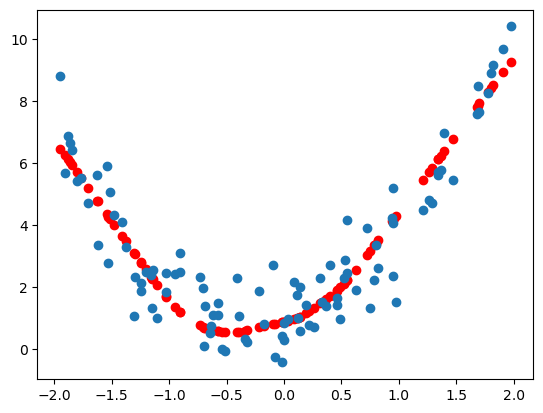

In [38]:
x_observe =  X.detach().numpy()
pred = best_model.forward(torch.tensor(x_observe)).squeeze(1).detach().numpy()
#pred = mean_train
plt.scatter(x_observe, pred, color = 'red')
plt.scatter(x_observe, y.detach().numpy())

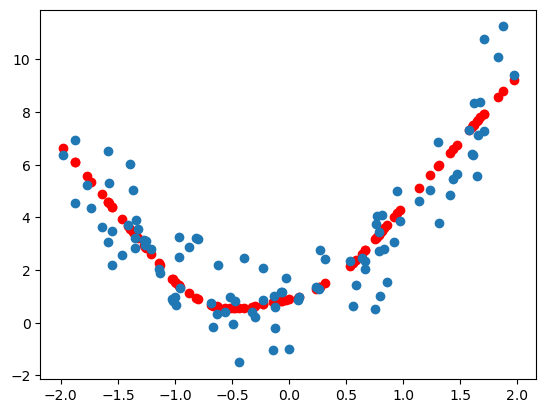

In [39]:
x_test =  X_test.detach().numpy()
#pred = best_model.forward(torch.tensor(x_test)).squeeze(1).detach().numpy()
pred = mean
plt.scatter(x_test, pred, color = 'red')
plt.scatter(x_test, y_test)

In [8]:

# MCMC    
mean_MC_l = []
if second_stage:
    for i in range(n_boot):
        mean_MC_l_2 = []
        for j in range(n_sample_mean):
            X_new,y_new, _, _,_,beta = generate_NN_data(N, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, 
                                                        X_test = None, if_tensor = True, uniform_range= uniform_range)
            model = neural_net_func.FF_neural_net(input_size = input_size, h_sizes = h_sizes, out_size = out_size, batchnorm_ind = False)
            mean_MC_l_2.append(neural_net_func.nn_fit_predict(model, y_new, X_new, X_test, n_iter = n_iter, lr = lr, device = device,  
                          patience = patience, weight_decay = weight_decay)[0])
        mean_MC_l.append(np.mean(mean_MC_l_2, axis = 0))
else:
    for i in range(n_boot):
        X_new, y_new, _, _,_,_ = generate_NN_data(N, N_test, p,  transform_X_poly, beta=beta, error_sd = 1, seed = None, X = None, 
                                                  X_test = None, if_tensor = True, uniform_range= uniform_range)
        model = neural_net_func.FF_neural_net(input_size = input_size, h_sizes = h_sizes, out_size = out_size, batchnorm_ind = False)
        mean_MC_l.append(neural_net_func.nn_fit_predict(model, y_new, X_new, X_test, n_iter = n_iter, lr = lr, device = device,  
                      patience = patience, weight_decay = weight_decay)[0])

mean_MC_l = np.array(mean_MC_l)
se_MC = np.std(mean_MC_l, axis = 0)
mean_MC = np.mean(mean_MC_l, axis = 0)

In [9]:
np.mean(np.abs(mean_train - y.numpy()))

1.4987799440033662

In [10]:
if pred_on_y:
    mean_true = y_test
else:
    mean_true = mean_test_true
use_a_true = False
a_true = np.quantile(np.max(np.abs((mean_MC_l - mean_test_true)/se_MC),axis = 1), q = 0.975)
print(a_true)
minus_mean = np.mean(mean_boot_l, axis = 0)
#minus_mean = mean
a = np.quantile(np.max(np.abs((mean_boot_l - minus_mean)/se),axis = 1), q = 0.975)
print(a)
est = mean
#est = mean_bias_cor1
if use_a_true:
    print(np.all(np.logical_and(est+a_true*se>mean_true, est - a_true*se < mean_true)))
else:
    print(np.all(np.logical_and(est+a*se>mean_true, est - a*se < mean_true)))

4.081368216020481
3.6999847808156248
True


1.8885238544430287
0.6355586224451797
6.52373468807216
4.935632388836341
1.9210280651850113
0.8746481215231442
4.736779353315759
3.0263166907215866
1.8536652981656616
0.4008499956703259
5.399345876128743
3.3848447135147968
2.002732146423779
0.9441027731358649
6.820195131135237
6.03401132573132
1.8885238544430287
0.6355586224451797
6.52373468807216
4.935632388836341


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:33: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.


IndexError: index 100 is out of bounds for axis 1 with size 100

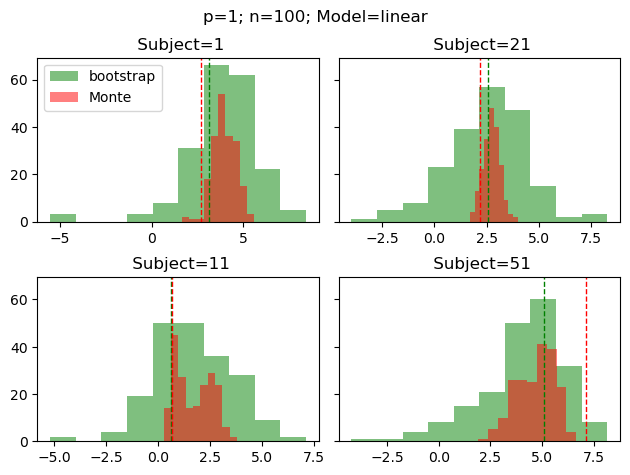

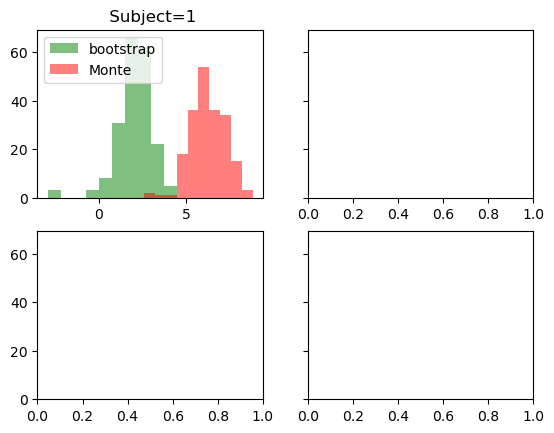

In [13]:
fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,11,21,51):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i], color = 'red', alpha=0.5, label = 'Monte')
    axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    #axs[q1,q2].axvline(mean_bias_cor1[i], color='yellow', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' 
#title = title+'; sparsity='+str(sparsity)
if second_stage:
    title = 'Second stage boot; '+ title
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')


fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,100,200,300):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i]/se[i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i]/se_MC[i], color = 'red', alpha=0.5, label = 'Monte')
    # axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    # #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
    # axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' 
#title = title+'; sparsity='+str(sparsity)+'; standardized'
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
#fig.savefig('../results/'+title+'.png')

# G = (mean_boot_l-np.mean(mean_boot_l,axis = 0))/se
# #np.mean(mean_boot_l,axis = 0)
# G_MC = (mean_MC_l-mean_test_true)/se_MC
# plt.hist(G[:,i], color = 'yellow', alpha=0.5)
# plt.hist(G_MC[:,i], color = 'red', alpha=0.5)
# plt.show()
# print(np.std(G[:,i]))
# print(np.std(G_MC[:,i]))
# print(np.quantile(G[:,i], q = 0.95))
# print(np.quantile(G_MC[:,i], q = 0.95))
# print(np.quantile(G[:,i], q = 0.1))
# print(np.quantile(G_MC[:,i], q = 0.1))
# print(np.quantile(np.abs(G[:,i]), q = 0.95))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.95))
# print(np.quantile(np.abs(G[:,i]), q = 0.1))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.1))

In [ ]:
!python3 ../functions/main_NN.py